In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier


In [8]:
df=pd.read_csv('C:\\Users\\User\\OneDrive\\Desktop\\python\\student_performance.csv')

In [9]:
df

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,NaN,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True


In [10]:
#drop  Nan Values
df.dropna(inplace=True)

In [11]:
df

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
6,7.0,Daniel,Male,70.0,8.0,60.0,0.0,Low,62.0,4.5,96.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
989,2116.0,Kimberly Pena,Female,91.0,30.0,88.0,2.0,High,68.0,3.6,79.0,False
991,7701.0,Anna Martinez,Male,85.0,30.0,70.0,3.0,Medium,90.0,0.4,76.0,False
993,3592.0,Monica Johnson,Female,90.0,25.0,60.0,1.0,Low,87.0,1.7,79.0,False
994,2787.0,Shannon Porter,Male,78.0,20.0,60.0,0.0,High,62.0,1.6,70.0,False


In [15]:
#remmove the columns that are not needed for the analysis
df = df.drop(['StudentID', 'Name', 'Gender', 'ExtracurricularActivities', 'ParentalSupport', 'Online Classes Taken'], axis=1)

In [16]:
df

,AttendanceRate,StudyHoursPerWeek,PreviousGrade,FinalGrade,Study Hours,Attendance (%)
0,85.0,15.0,78.0,80.0,4.8,59.0
1,90.0,20.0,85.0,87.0,2.2,70.0
2,78.0,10.0,65.0,68.0,4.6,92.0
3,92.0,25.0,90.0,92.0,2.9,96.0
6,70.0,8.0,60.0,62.0,4.5,96.0
...,...,...,...,...,...,...
989,91.0,30.0,88.0,68.0,3.6,79.0
991,85.0,30.0,70.0,90.0,0.4,76.0
993,90.0,25.0,60.0,87.0,1.7,79.0
994,78.0,20.0,60.0,62.0,1.6,70.0


In [17]:
#add extra column to the dataset to indicate whether the student passed or failed based on their final grade
df['Pass/Fail'] = np.where(df['FinalGrade'] >= 70, 'Pass', 'Fail')

In [18]:
df

,AttendanceRate,StudyHoursPerWeek,PreviousGrade,FinalGrade,Study Hours,Attendance (%),Pass/Fail
0,85.0,15.0,78.0,80.0,4.8,59.0,Pass
1,90.0,20.0,85.0,87.0,2.2,70.0,Pass
2,78.0,10.0,65.0,68.0,4.6,92.0,Fail
3,92.0,25.0,90.0,92.0,2.9,96.0,Pass
6,70.0,8.0,60.0,62.0,4.5,96.0,Fail
...,...,...,...,...,...,...,...
989,91.0,30.0,88.0,68.0,3.6,79.0,Fail
991,85.0,30.0,70.0,90.0,0.4,76.0,Pass
993,90.0,25.0,60.0,87.0,1.7,79.0,Pass
994,78.0,20.0,60.0,62.0,1.6,70.0,Fail


In [19]:
X = df.drop(['FinalGrade', 'Pass/Fail'], axis=1)
y= df['Pass/Fail']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
#fit the decision tree classifier to the training data
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [25]:
#predict the pass/fail status of the test data
y_pred = clf.predict(X_test)
y_pred  

array(['Fail', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass',
       'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Fail', 'Fail',
       'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Fail',
       'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass',
       'Pass', 'Fail', 'Pass', 'Pass', 'Pass', 'Pass', 'Fail', 'Fail',
       'Pass', 'Pass', 'Fail', 'Pass', 'Fail', 'Fail', 'Pass', 'Pass',
       'Pass', 'Pass', 'Pass', 'Fail', 'Fail', 'Pass', 'Pass', 'Pass',
       'Pass', 'Pass', 'Pass', 'Pass', 'Fail', 'Fail', 'Pass', 'Pass',
       'Pass', 'Pass', 'Fail', 'Pass', 'Pass', 'Fail', 'Fail', 'Fail',
       'Pass', 'Fail', 'Fail', 'Pass', 'Fail', 'Pass', 'Pass', 'Pass',
       'Pass', 'Pass', 'Fail', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass',
       'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Fail', 'Pass', 'Pass',
       'Pass', 'Pass', 'Pass', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass',
       'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Fail', 'Pass', 'Fail',
      

In [26]:
#accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7209302325581395

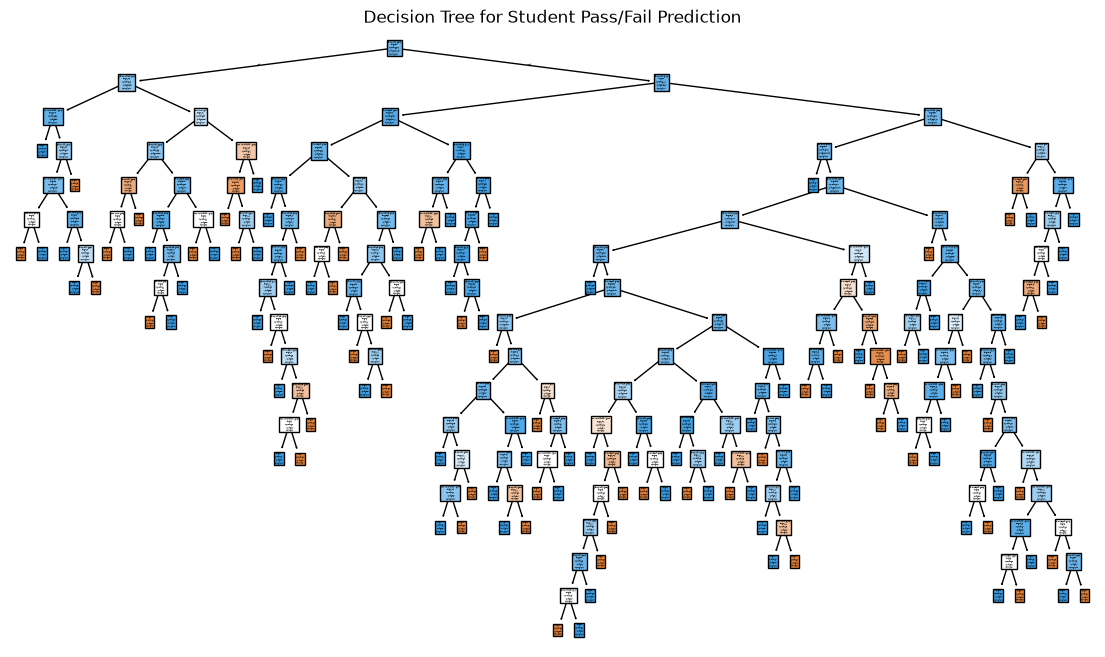

In [29]:
#matplotlib inline
import matplotlib.pyplot as plt 
from sklearn import tree

plt.figure(figsize=(14,8))
tree.plot_tree(clf, feature_names=X.columns, class_names=['Fail', 'Pass'], filled=True)
plt.title('Decision Tree for Student Pass/Fail Prediction')
plt.show()